### Simple code which uses MCMC for posterior evaluation

In [1]:
import numpy as np
import matplotlib.pyplot as plt

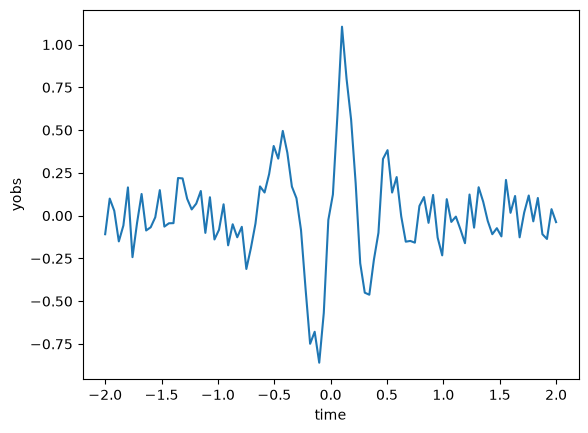

In [2]:
# Loading sample data from a file. This corresponds to observed data (signal + noise)
file = np.loadtxt('toy_model.csv', delimiter=",")
t=file[:,0]  #time
yobs = file[:,1]
plt.plot(t, yobs)
plt.xlabel('time')
plt.ylabel('yobs')
plt.show()

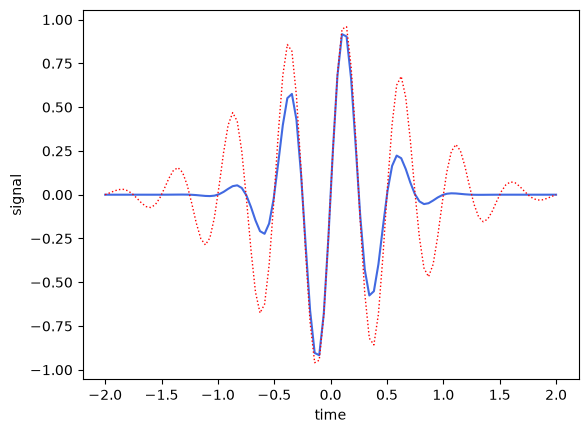

In [3]:
# Signal template or definition

def signal_model(time, frequency, alpha):
    sinusoid = np.sin(2 * np.pi * frequency * time)
    gaussian_exp= np.exp(-(time/alpha)**2)
    return gaussian_exp*sinusoid

alpha=0.5
frequency = 2
t = np.linspace(-2,2,100)
plt.plot(t, signal_model(t, frequency, alpha), color='royalblue')

alpha=1
frequency = 2
plt.plot(t, signal_model(t, frequency, alpha), ls='dotted', lw=1, color='red')

plt.ylabel('signal')
plt.xlabel('time')
plt.show()

In [4]:
def likelihood(time, alpha, frequency, sigma=0.1):
     observed_data = yobs
     signal_prediction = signal_model(time, frequency, alpha)

     residual = observed_data - signal_prediction

     #after residual is computed
     likelihood_val = np.sqrt(1/(2*np.pi*sigma))*np.exp(-residual/(2*sigma**2))  

     # better to have in log-form
     log_likelihood_val = -0.5 * (((residual/sigma)**2) + np.log(2 * np.pi * sigma**2))

     return np.sum(log_likelihood_val)
     

In [5]:
likelihood(t, 0.5, 2), likelihood(t, 1, 2)

(np.float64(-13.264736813077551), np.float64(-342.99358623246536))

Text(0, 0.5, 'alpha')

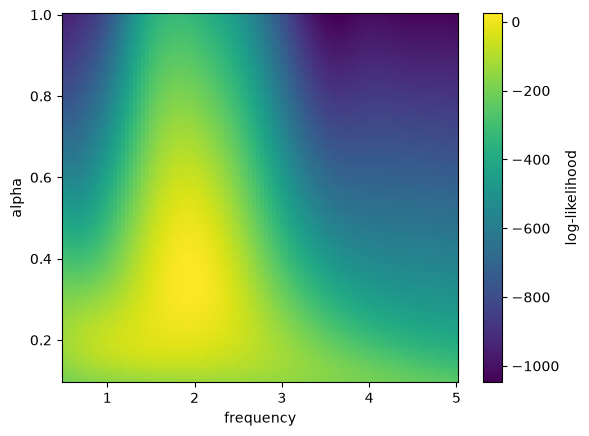

In [18]:
# Visualizing where likelihood peaks
alphas = np.linspace(0.1, 1.0, 100)
freqs  = np.linspace(0.5, 5.0, 100)

logL = np.array([[likelihood(t, a, f) for f in freqs] for a in alphas])

plt.pcolormesh(freqs, alphas, logL, shading='auto')
plt.colorbar(label='log-likelihood')
plt.xlabel('frequency')
plt.ylabel('alpha')

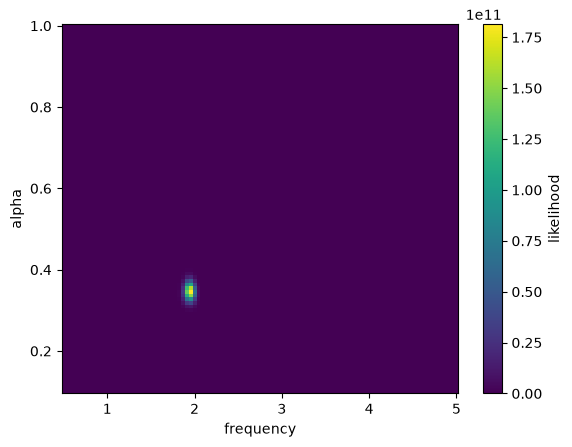

In [21]:
# Exponentiaing and conveting to likelihood
plt.xlabel('frequency')
plt.ylabel('alpha')
plt.pcolormesh(freqs, alphas, np.exp(logL), shading='auto')
plt.colorbar(label='likelihood')
plt.show()

Text(0, 0.5, 'alpha')

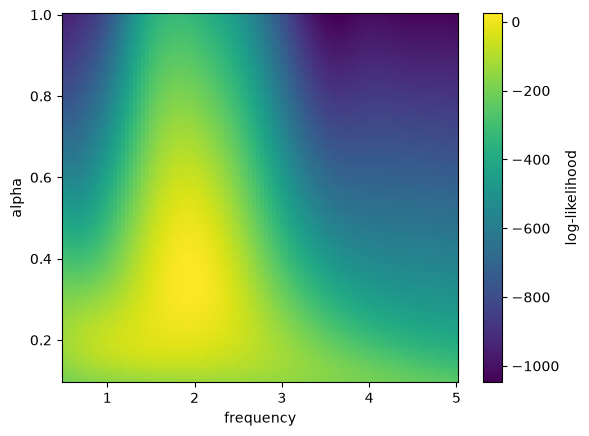

In [25]:
# We will use MCMC for posterior evaluation with bilby
import bilby
import corner

likelihood_sigmodel = bilby.core.likelihood.GaussianLikelihood(t, yobs, signal_model, sigma=0.1)   #we create likelihood object

alphas = np.linspace(0.1, 1.0, 100)
freqs  = np.linspace(0.5, 5.0, 100)
logL = np.empty((len(alphas), len(freqs)))

for i, a in enumerate(alphas):
    for j, f in enumerate(freqs):
        likelihood_sigmodel.parameters = {'alpha': a, 'frequency': f}   #defines parameters and passes one set of values
        logL[i, j] = likelihood_sigmodel.log_likelihood()              #evlauates at one a and f

plt.pcolormesh(freqs, alphas, logL, shading='auto')
plt.colorbar(label='log-likelihood')
plt.xlabel('frequency')
plt.ylabel('alpha')

In [8]:
priors_sigmodel = dict(
    frequency=bilby.core.prior.Uniform(0, 5, 'frequency'), 
    alpha=bilby.core.prior.Uniform(0, 1, 'alpha'))

In [9]:
import warnings
warnings.simplefilter('ignore', FutureWarning)

result_sigmodel = bilby.run_sampler(
    likelihood_sigmodel,
    priors_sigmodel, 
    label="signalmodel",  # A label to help sort our results
    outdir="toy_model",  # The directory where results will be kept
    clean=True,  # Don't use cached/previous data
    sampler="bilby_mcmc",  # Use the bilby_mcmc sampler
    nsamples=1000,  # Draw 1000 samples
    printdt=2,  # Print an update ever 5 seconds
    L1steps=1,  # The number of internal steps to take
)

#run_sampler method returns an object result

22:01 bilby INFO    : Running for label 'signalmodel', output will be saved to 'toy_model'
22:01 bilby INFO    : Analysis priors:
22:01 bilby INFO    : frequency=Uniform(minimum=0, maximum=5, name='frequency', latex_label='frequency', unit=None, boundary=None)
22:01 bilby INFO    : alpha=Uniform(minimum=0, maximum=1, name='alpha', latex_label='alpha', unit=None, boundary=None)
22:01 bilby INFO    : Analysis likelihood class: <class 'bilby.core.likelihood.GaussianLikelihood'>
22:01 bilby INFO    : Analysis likelihood noise evidence: nan
22:01 bilby INFO    : Single likelihood evaluation took 1.981e-05 s
22:01 bilby INFO    : Using sampler Bilby_MCMC with kwargs {'nsamples': 1000, 'nensemble': 1, 'pt_ensemble': False, 'ntemps': 1, 'Tmax': None, 'Tmax_from_SNR': 20, 'initial_betas': None, 'adapt': True, 'adapt_t0': 100, 'adapt_nu': 10, 'pt_rejection_sample': False, 'burn_in_nact': 10, 'thin_by_nact': 1, 'fixed_discard': 0, 'autocorr_c': 5, 'L1steps': 1, 'L2steps': 3, 'printdt': 2, 'check_

1.87e+04|0:00:02|2.12e+02(z1)|t=9|n=2076|a=0.48|e=1.1e+01%|0.11ms/ev|maxl=25.99|ETF=0


22:01 bilby WARNING : Non-negligible print progress time (ppt_frac=0.06)
22:01 bilby INFO    : Reached convergence: exiting sampling
22:01 bilby INFO    : Checkpoint start
22:01 bilby INFO    : Written checkpoint file toy_model/signalmodel_resume.pickle
22:01 bilby INFO    : Zero-temperature proposals:
22:01 bilby INFO    : AdaptiveGaussianProposal(acceptance_ratio:0.23,n:3.7e+03,scale:0.034,)
22:01 bilby INFO    : DifferentialEvolutionProposal(acceptance_ratio:0.45,n:3.8e+03,)
22:01 bilby INFO    : UniformProposal(acceptance_ratio:1,n:2.2e+02,)
22:01 bilby INFO    : KDEProposal(acceptance_ratio:0.59,n:3.2e+03,trained:1,)
22:01 bilby INFO    : FisherMatrixProposal(acceptance_ratio:0.55,n:3.9e+03,scale:1,)
22:01 bilby INFO    : GMMProposal(acceptance_ratio:0.57,n:3.8e+03,trained:1,)
22:01 bilby INFO    : Current taus={'frequency': np.float64(7.5), 'alpha': np.float64(8.9)}
22:01 bilby INFO    : Creating diagnostic plots
22:01 bilby INFO    : Checkpoint finished
22:01 bilby INFO    : Sam

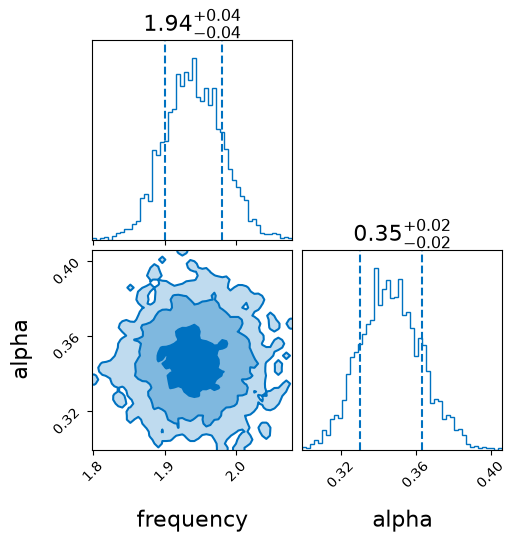

In [10]:
# Extracting information and doing corner plot

result_sigmodel.plot_corner()

In [11]:
result_sigmodel.posterior

,frequency,alpha,log_likelihood,log_prior
0,2.009098,0.349776,24.472466,-1.609438
1,1.899935,0.351308,25.404754,-1.609438
2,1.888245,0.347837,25.093663,-1.609438
3,1.976290,0.325848,24.787283,-1.609438
4,2.013844,0.322842,23.371837,-1.609438
...,...,...,...,...
2306,1.921552,0.347285,25.863703,-1.609438
2307,1.912976,0.335118,25.480136,-1.609438
2308,1.899030,0.344828,25.418219,-1.609438
2309,1.879893,0.341889,24.765535,-1.609438


In [23]:
# We will use EMCEE for posterior evaluation

import emcee

def log_prior(theta):
    alpha, frequency = theta
    if 0.1 < alpha < 1.0 and 0.5 < frequency < 5.0:
        return 0.0
    return -np.inf

def log_posterior(theta, t):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    alpha, frequency = theta
    return lp + likelihood(t, alpha, frequency)

nwalkers, ndim, nsteps = 32, 2, 10000

initial = np.column_stack([
    np.random.uniform(0.1, 1.0, nwalkers),
    np.random.uniform(0.5, 5.0, nwalkers),
])

sampler = emcee.EnsembleSampler(nwalkers, ndim, log_posterior, args=(t,))
sampler.run_mcmc(initial, nsteps, progress=True)

100%|██████████████████████████████████████████████████████████████████████████| 10000/10000 [00:02<00:00, 3579.69it/s]


State([[0.34853315 1.95928963]
 [0.33998499 1.992772  ]
 [0.40020961 1.97915509]
 [0.36297068 1.99883281]
 [0.34090498 1.93826058]
 [0.37400066 1.96441701]
 [0.33803958 1.98304143]
 [0.32957215 1.97025617]
 [0.33404721 1.97274816]
 [0.3400891  1.99038894]
 [0.36226859 2.01125774]
 [0.33167183 1.88058046]
 [0.37376688 1.93183349]
 [0.33876768 1.86188873]
 [0.34147826 1.90245694]
 [0.35544106 2.00138708]
 [0.33503345 1.90156963]
 [0.36409661 2.03094346]
 [0.32965413 1.93666976]
 [0.34730373 1.990493  ]
 [0.3527597  1.95778651]
 [0.39081488 1.89765216]
 [0.33508897 1.90550636]
 [0.34410144 1.90426764]
 [0.34660308 1.92960838]
 [0.34828667 1.95610463]
 [0.3370508  1.91628184]
 [0.34291677 1.88907003]
 [0.34619856 1.83244576]
 [0.34656062 1.86832694]
 [0.35263167 1.94016435]
 [0.34024619 1.94907162]], log_prob=[25.87141068 25.07827582 20.21019584 24.3294698  25.91748404 24.39513745
 25.30698242 25.17162077 25.37999716 25.15466932 23.8342036  24.44001324
 24.62537214 23.92002317 25.46297348 

alpha: 0.3469 +0.0162 -0.016
frequency: 1.941 +0.0393 -0.0393


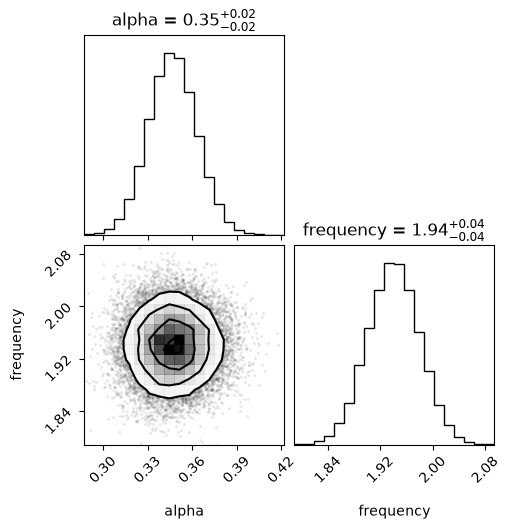

In [24]:
# Measure the autocorrelation time, then discard burn-in and thin
# so the remaining samples are effectively independent draws
tau = sampler.get_autocorr_time()
flat = sampler.get_chain(discard=int(5*tau.max()), thin=int(0.5*tau.min()), flat=True)

corner.corner(flat, labels=['alpha', 'frequency'], show_titles=True)

for i, lab in enumerate(['alpha', 'frequency']):
    lo, med, hi = np.percentile(flat[:, i], [16, 50, 84])
    print(f"{lab}: {med:.4g} +{hi-med:.3g} -{med-lo:.3g}")